# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import scipy.constants as const
from tqdm import tqdm

# Constants

In [2]:
H = const.h # plancks constant
C = const.c # speed of light
PI = np.pi
AMU = 1.66e-27
kb = const.k

############ TRANSITIONS
gamma_689, lambda_689 = 2*PI*7.48e3, 689.4489e-9
gamma_688, lambda_688 = 2*PI*3.9e6, 688.020770e-9
gamma_679, lambda_679 = 2*PI*1.26e6, 679.288943e-9

########### sat intensities (uW/cm^2) ## UNITS!!
Ipref = H*C*np.pi/3  # prefactor for calc sat intensities

Is_689 = Ipref * gamma_689/(lambda_689**3) * 100
Is_688 = Ipref * gamma_688/(lambda_688**3) * 100
Is_679 = Ipref * gamma_679/(lambda_679**3) * 100

# GEOMETRY DEFINITIONS

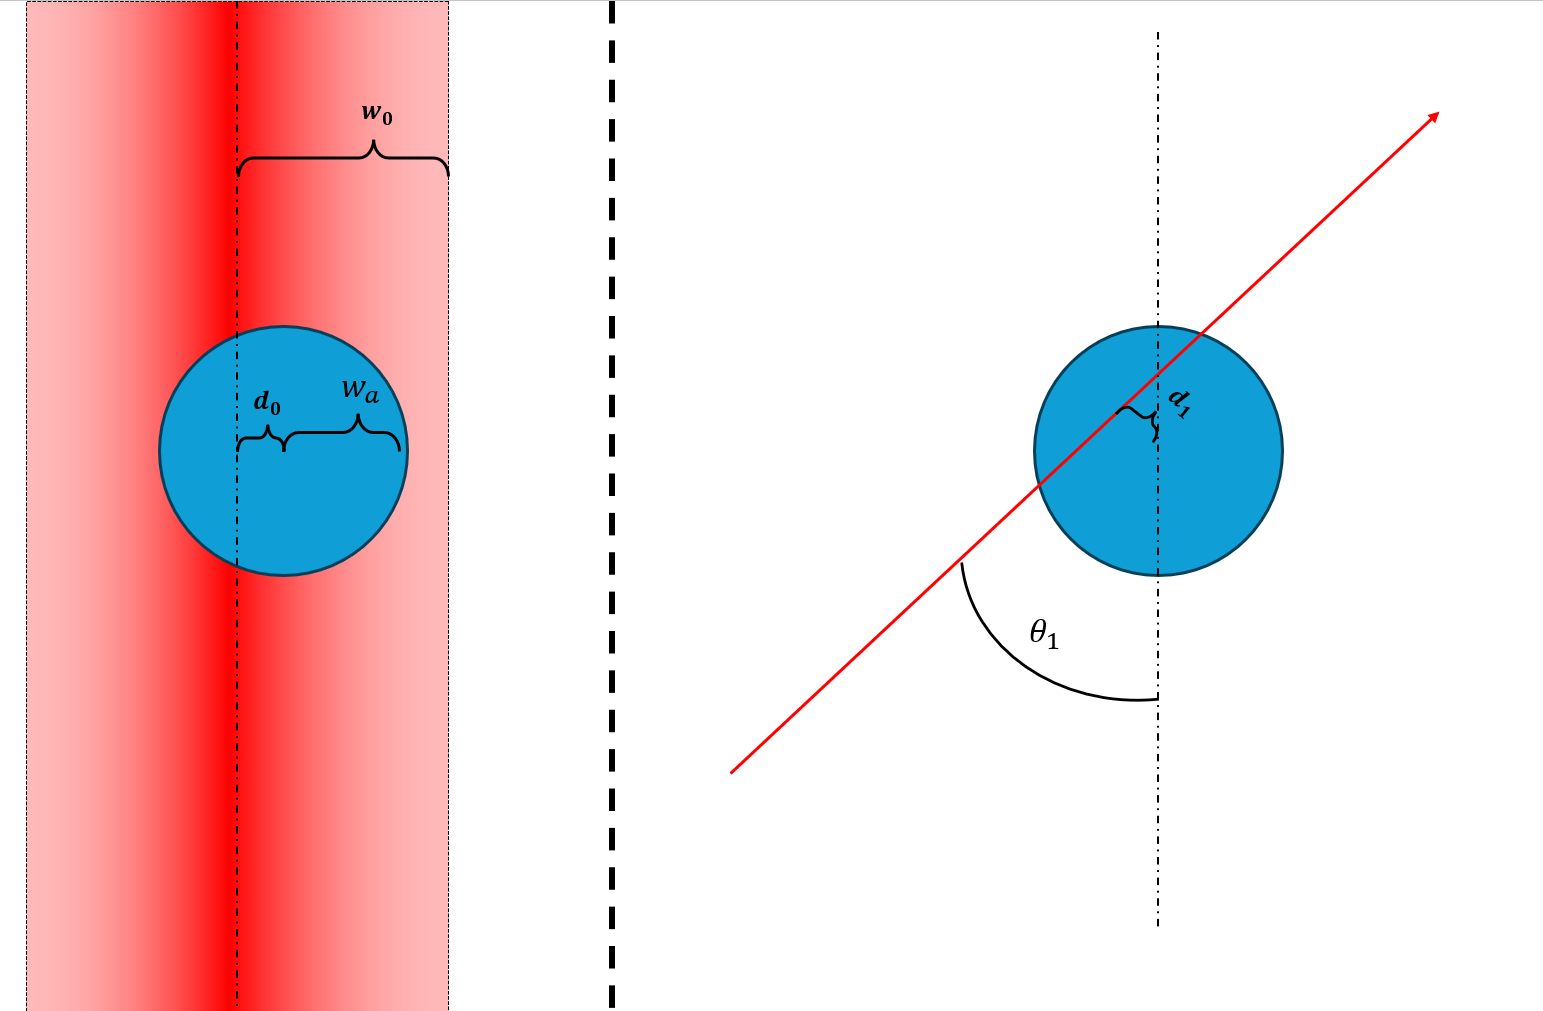

# Parameters

In [5]:
########### DEFINE BEAM GEOMETRIES (SEE ABOVE CELL FOR DEFINITIONS)
# Angles
theta_1, theta_1z = np.radians(59.4384), 0.0
theta_2, theta_2z = np.radians(-59.64), 0.0
theta_0, theta_0z = 0.0, 0.0
#linear offsets (distance between center of laser beam and center of atomic cloud)
d0, d1, d2 = 0.0, 0.0, 0.0

# --- BEAM / CLOUD PARAMETERS ---
wa = 35e-6
w0 = 1e-3
w1 = 1e-3
w2 = 1e-3
temp = 2e-6
P_689, P_688, P_679 = 10e-3, 7.5e-3, 2.5e-3

def get_k_hat(theta, theta_z):
        return np.array([np.cos(theta_z)*np.cos(theta), np.cos(theta_z)*np.sin(theta), np.sin(theta_z)])

k_hat_0, k_hat_1, k_hat_2 = get_k_hat(theta_0, theta_0z), get_k_hat(theta_1, theta_1z), get_k_hat(theta_2, theta_2z)
k_vec_0, k_vec_1, k_vec_2 = k_hat_0 * (2*PI/lambda_689), k_hat_1 * (2*PI/lambda_688), k_hat_2 * (2*PI/lambda_679)

# SAMPLING POSITION AND VELOCITY

In [6]:
def sample_atomic_ensemble(radii, temperatures, mass=88*AMU, n_samples=1):    
    # Convert inputs to numpy arrays for element-wise operations
    sigma_r = np.array(radii)
    T = np.array(temperatures)
    
    # Calculate the velocity standard deviations based on the Maxwell-Boltzmann distribution
    sigma_v = np.sqrt(kb * T / mass)
    
    # Sample positions/velocities from a normal distribution centered at 0
    positions = np.random.normal(loc=0.0, scale=sigma_r, size=(n_samples, 3))
    velocities = np.random.normal(loc=0.0, scale=sigma_v, size=(n_samples, 3))
    
    # If only one sample is requested, return 1D arrays instead of 2D
    if n_samples == 1:
        return positions[0], velocities[0]
        
    return positions, velocities


## SAMPLING TESTS

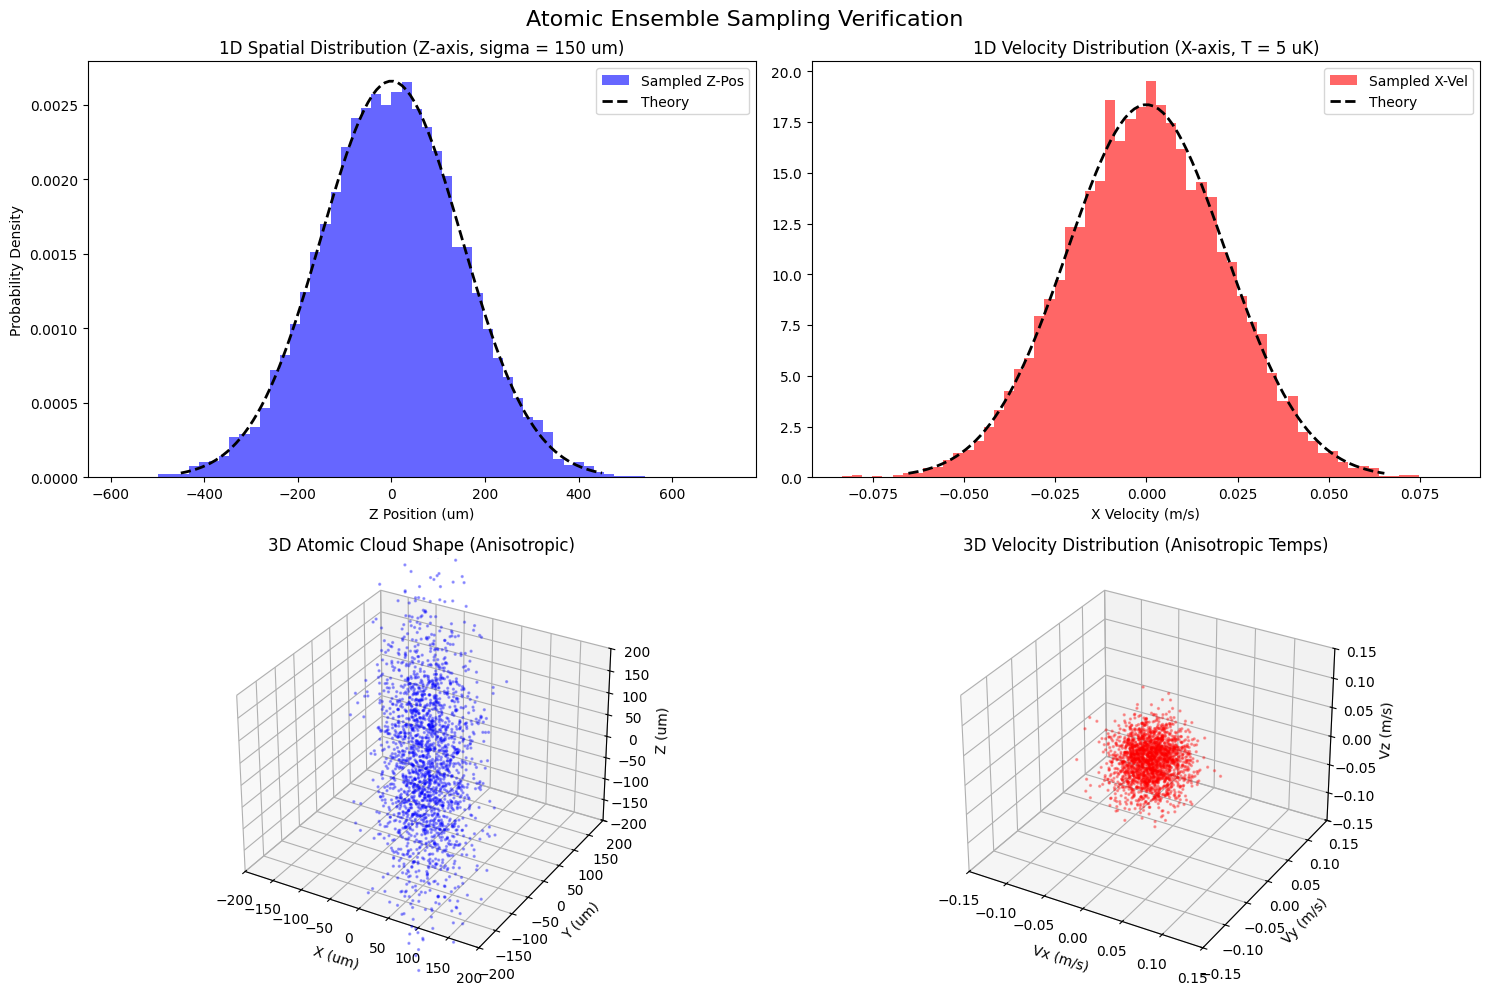

In [12]:
N_ATOMS = 15000
# Cigar-shaped cloud: 35 um in x/y, 150 um in z
cloud_radii = (35e-6, 35e-6, 150e-6)
# Hotter in x/y (50 uK), colder in z (10 uK)
cloud_temps = (5e-6, 5e-6, 10e-6)
mass = 88 * AMU

# Sample the ensemble
pos, vel = sample_atomic_ensemble(cloud_radii, cloud_temps, mass, n_samples=N_ATOMS)

# Convert to standard plotting units (um for pos, m/s for vel)
pos_um = pos * 1e6

# --- FIGURE SETUP ---
fig = plt.figure(figsize=(15, 10))
fig.suptitle("Atomic Ensemble Sampling Verification", fontsize=16)

# ==========================================
# 1D TESTS: Histograms vs Theoretical Curves
# ==========================================

# 1D Position (Z-axis)
ax1 = fig.add_subplot(2, 2, 1)
ax1.hist(pos_um[:, 2], bins=60, density=True, alpha=0.6, color='blue', label='Sampled Z-Pos')

# Theoretical Gaussian for Z-Position
z_val = np.linspace(-3*cloud_radii[2]*1e6, 3*cloud_radii[2]*1e6, 100)
sigma_z_um = cloud_radii[2] * 1e6
ideal_z = (1/(sigma_z_um * np.sqrt(2*np.pi))) * np.exp(-0.5 * (z_val/sigma_z_um)**2)
ax1.plot(z_val, ideal_z, 'k--', linewidth=2, label='Theory')

ax1.set_title(f"1D Spatial Distribution (Z-axis, sigma = {sigma_z_um:.0f} um)")
ax1.set_xlabel("Z Position (um)")
ax1.set_ylabel("Probability Density")
ax1.legend()

# 1D Velocity (X-axis)
ax2 = fig.add_subplot(2, 2, 2)
ax2.hist(vel[:, 0], bins=60, density=True, alpha=0.6, color='red', label='Sampled X-Vel')

# Theoretical Gaussian for X-Velocity
sigma_vx = np.sqrt(kb * cloud_temps[0] / mass)
vx_val = np.linspace(-3*sigma_vx, 3*sigma_vx, 100)
ideal_vx = (1/(sigma_vx * np.sqrt(2*np.pi))) * np.exp(-0.5 * (vx_val/sigma_vx)**2)
ax2.plot(vx_val, ideal_vx, 'k--', linewidth=2, label='Theory')

ax2.set_title(f"1D Velocity Distribution (X-axis, T = {cloud_temps[0]*1e6:.0f} uK)")
ax2.set_xlabel("X Velocity (m/s)")
ax2.legend()

# ==========================================
# 3D TESTS: Spatial and Velocity Scatter
# ==========================================
# Reduce points for 3D scatter to avoid rendering a solid blob
plot_points = 2000 

# 3D Position Cloud
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.scatter(pos_um[:plot_points, 0], pos_um[:plot_points, 1], pos_um[:plot_points, 2], 
            s=2, alpha=0.3, color='blue')
ax3.set_title("3D Atomic Cloud Shape (Anisotropic)")
ax3.set_xlabel("X (um)")
ax3.set_ylabel("Y (um)")
ax3.set_zlabel("Z (um)")
# Set equal axis limits to show the true aspect ratio (cigar shape)
lim_pos = 200
ax3.set_xlim([-lim_pos, lim_pos])
ax3.set_ylim([-lim_pos, lim_pos])
ax3.set_zlim([-lim_pos, lim_pos])

# 3D Velocity Distribution
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.scatter(vel[:plot_points, 0], vel[:plot_points, 1], vel[:plot_points, 2], 
            s=2, alpha=0.3, color='red')
ax4.set_title("3D Velocity Distribution (Anisotropic Temps)")
ax4.set_xlabel("Vx (m/s)")
ax4.set_ylabel("Vy (m/s)")
ax4.set_zlabel("Vz (m/s)")
lim_vel = 0.15
ax4.set_xlim([-lim_vel, lim_vel])
ax4.set_ylim([-lim_vel, lim_vel])
ax4.set_zlim([-lim_vel, lim_vel])

plt.tight_layout()
plt.show()

# CALCULATE PARAMETERS

In [13]:
def get_effective_r_perp(pos, k_hat, d):
    # Vectorized for Nx3 pos array
    # 1. Dot product along axis=1: (N,) shape
    proj_mag = np.sum(pos * k_hat, axis=1)
    
    # 2. Outer product to get vector components back: (N, 3) shape
    r_parallel = np.outer(proj_mag, k_hat)
    
    # 3. Perpendicular vector component
    r_perp_vec = pos - r_parallel
    
    # 4. Norm along axis=1 plus scalar offset
    return np.linalg.norm(r_perp_vec, axis=1) - d

    
def get_calculated_parameters(position, velocity, d=np.zeros(3)):
    # np.dot behaves differently for 2D arrays, using element-wise sum for dot product across N atoms
    doppler_0 = -np.sum(k_vec_0 * velocity, axis=1)
    doppler_1 = -np.sum(k_vec_1 * velocity, axis=1)
    doppler_2 = -np.sum(k_vec_2 * velocity, axis=1)

    r_perp_0 = get_effective_r_perp(position, k_hat_0, d[0])
    r_perp_1 = get_effective_r_perp(position, k_hat_1, d[1])
    r_perp_2 = get_effective_r_perp(position, k_hat_2, d[2])

    # Gaussian Beam Intensity: I(r) = (2P / pi w^2) * exp(-2 * r^2 / w^2)
    # uW/m^2
    I0 = (2 * P_689 / (np.pi * w0**2)) * np.exp(-2 * (r_perp_0**2) / w0**2) * 100
    I1 = (2 * P_688 / (np.pi * w1**2)) * np.exp(-2 * (r_perp_1**2) / w1**2) * 100
    I2 = (2 * P_679 / (np.pi * w2**2)) * np.exp(-2 * (r_perp_2**2) / w2**2) * 100
    
    # 5. Calculate Rabi Frequencies
    rabi_0 = gamma_689 * np.sqrt(I0 / (2 * Is_689))
    rabi_1 = gamma_688 * np.sqrt(I1 / (2 * Is_688))
    rabi_2 = gamma_679 * np.sqrt(I2 / (2 * Is_679))

    # Package and return all parameters
    return {
        "beam_0": {
            "dshift": doppler_0,
            "Omega": rabi_0
        },
        "beam_1": {
            "dshift": doppler_1,
            "Omega": rabi_1
        },
        "beam_2": {
            "dshift": doppler_2,
            "Omega": rabi_2
        }
    }




## Test calculated parameters

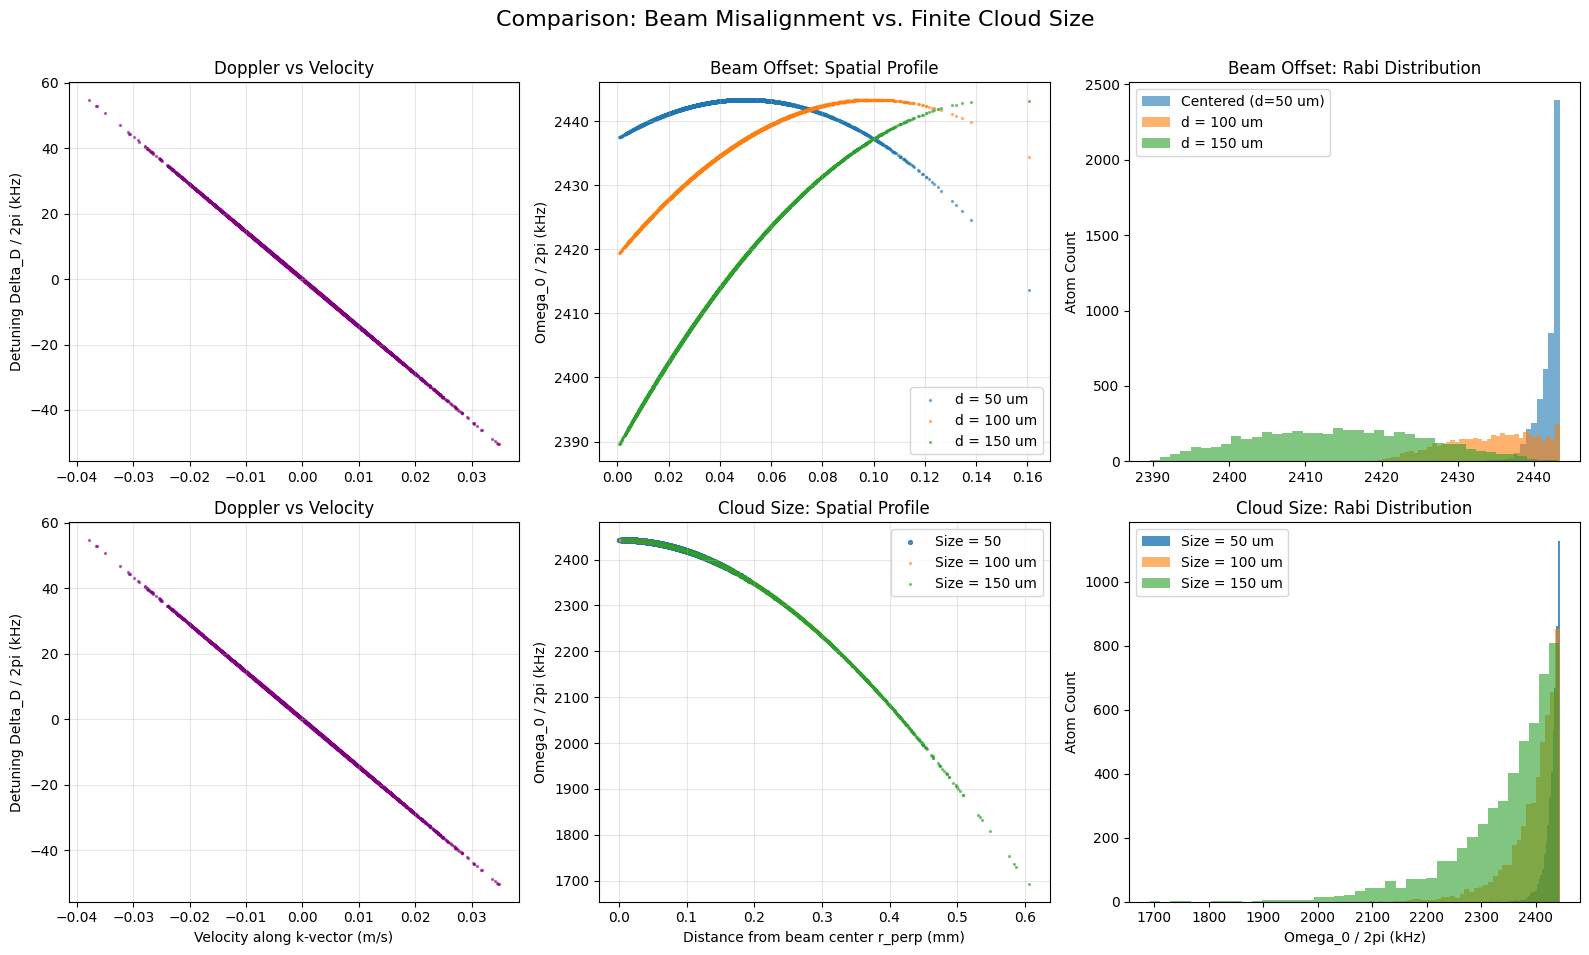

In [14]:
N_ATOMS = 5000
vel = np.random.normal(0, 0.01, size=(N_ATOMS, 3))
vel_proj = np.sum(vel * k_hat_0, axis=1)

# ROW 1: Fixed Cloud Size (35 um), Varying Offsets
pos_fixed = np.random.normal(0, 35e-6, size=(N_ATOMS, 3))
r_perp_fixed = get_effective_r_perp(pos_fixed, k_hat_0, 0)

params_r1_cent = get_calculated_parameters(pos_fixed, vel, d=[50e-6, 0, 0])
params_r1_off1 = get_calculated_parameters(pos_fixed, vel, d=[100e-6, 0, 0])
params_r1_off2 = get_calculated_parameters(pos_fixed, vel, d=[150e-6, 0, 0])

# ROW 2: Zero Offset, Varying Cloud Sizes
pos_size50   = np.random.normal(0, 50e-6, size=(N_ATOMS, 3))
pos_size100  = np.random.normal(0, 100e-6, size=(N_ATOMS, 3))
pos_size150 = np.random.normal(0, 150e-6, size=(N_ATOMS, 3))


r_perp_s50   = get_effective_r_perp(pos_size50, k_hat_0, 0)
r_perp_s100  = get_effective_r_perp(pos_size100, k_hat_0, 0)
r_perp_s150 = get_effective_r_perp(pos_size150, k_hat_0, 0)


params_r2_s50   = get_calculated_parameters(pos_size50, vel, d=[0,0,0])
params_r2_s100  = get_calculated_parameters(pos_size100, vel, d=[0,0,0])
params_r2_s150 = get_calculated_parameters(pos_size150, vel, d=[0,0,0])


# --- PLOTTING ---
fig, axs = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Comparison: Beam Misalignment vs. Finite Cloud Size", fontsize=16, y=0.98)

# ==========================================
# ROW 1: Fixed Cloud, Varying Offset
# ==========================================
# 1,1. Doppler Shift
axs[0, 0].scatter(vel_proj, params_r1_cent["beam_0"]["dshift"] / (2*PI*1e3), s=2, alpha=0.5, color='purple')
axs[0, 0].set_title("Doppler vs Velocity")
axs[0, 0].set_ylabel("Detuning Delta_D / 2pi (kHz)")
axs[0, 0].grid(True, alpha=0.3)

# 1,2. Rabi vs Radial Distance
axs[0, 1].scatter(r_perp_fixed * 1e3, params_r1_cent["beam_0"]["Omega"] / (2*PI*1e3), s=2, alpha=0.5, label='d = 50 um')
axs[0, 1].scatter(r_perp_fixed * 1e3, params_r1_off1["beam_0"]["Omega"] / (2*PI*1e3), s=2, alpha=0.5, label='d = 100 um')
axs[0, 1].scatter(r_perp_fixed * 1e3, params_r1_off2["beam_0"]["Omega"] / (2*PI*1e3), s=2, alpha=0.5, label='d = 150 um')
axs[0, 1].set_title("Beam Offset: Spatial Profile")
axs[0, 1].set_ylabel("Omega_0 / 2pi (kHz)")
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# 1,3. Ensemble Histogram
axs[0, 2].hist(params_r1_cent["beam_0"]["Omega"] / (2*PI*1e3), bins=40, alpha=0.6, label='Centered (d=50 um)')
axs[0, 2].hist(params_r1_off1["beam_0"]["Omega"] / (2*PI*1e3), bins=40, alpha=0.6, label='d = 100 um')
axs[0, 2].hist(params_r1_off2["beam_0"]["Omega"] / (2*PI*1e3), bins=40, alpha=0.6, label='d = 150 um')
axs[0, 2].set_title("Beam Offset: Rabi Distribution")
axs[0, 2].set_ylabel("Atom Count")
axs[0, 2].legend()

# ==========================================
# ROW 2: Zero Offset, Varying Cloud Size
# ==========================================
# 2,1. Doppler Shift (Identical because velocity spread is identical)
axs[1, 0].scatter(vel_proj, params_r2_s50["beam_0"]["dshift"] / (2*PI*1e3), s=2, alpha=0.5, color='purple')
axs[1, 0].set_title("Doppler vs Velocity")
axs[1, 0].set_xlabel("Velocity along k-vector (m/s)")
axs[1, 0].set_ylabel("Detuning Delta_D / 2pi (kHz)")
axs[1, 0].grid(True, alpha=0.3)

# 2,2. Rabi vs Radial Distance (Shows how atoms populate the beam profile)
axs[1, 1].scatter(r_perp_s50 * 1e3, params_r2_s50["beam_0"]["Omega"] / (2*PI*1e3), s=8, alpha=0.8, label='Size = 50')
axs[1, 1].scatter(r_perp_s100 * 1e3, params_r2_s100["beam_0"]["Omega"] / (2*PI*1e3), s=2, alpha=0.5, label='Size = 100 um')
axs[1, 1].scatter(r_perp_s150 * 1e3, params_r2_s150["beam_0"]["Omega"] / (2*PI*1e3), s=2, alpha=0.5, label='Size = 150 um')
axs[1, 1].set_title("Cloud Size: Spatial Profile")
axs[1, 1].set_xlabel("Distance from beam center r_perp (mm)")
axs[1, 1].set_ylabel("Omega_0 / 2pi (kHz)")
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=0.3)

# 2,3. Ensemble Histogram
axs[1, 2].hist(params_r2_s50["beam_0"]["Omega"] / (2*PI*1e3), bins=40, alpha=0.8, label='Size = 50 um')
axs[1, 2].hist(params_r2_s100["beam_0"]["Omega"] / (2*PI*1e3),bins=40, alpha=0.6, label='Size = 100 um')
axs[1, 2].hist(params_r2_s150["beam_0"]["Omega"] / (2*PI*1e3), bins=40, alpha=0.6, label='Size = 150 um')
axs[1, 2].set_title("Cloud Size: Rabi Distribution")
axs[1, 2].set_xlabel("Omega_0 / 2pi (kHz)")
axs[1, 2].set_ylabel("Atom Count")
axs[1, 2].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# 1 Photon Dynamics

In [15]:
# --- QUTIP SIMULATION ---
def simulate_one_photon_rabi_dynamics(positions, velocities, d0=0, t_max=20e-6, dt=10e-9, detuning=0):
    """
    Simulates the atomic ensemble using the QuTiP master equation.
    Returns the time array and the averaged excited state population.
    """
    N_atoms = positions.shape[0]
    n_steps = int(t_max/dt) + 1
    tlist = np.linspace(0, t_max, n_steps)
    
    # Define Quantum Operators for a 2-level system
    # g = |0>, e = |1>
    g = qt.basis(2, 0)
    e = qt.basis(2, 1)
    sm = qt.destroy(2)      # Lowering operator (|e><g|)
    sp = qt.create(2)       # Raising operator (|g><e|)
    proj_e = sp * sm        # Excited state projector (|e><e|)
    
    # Initial state (all atoms in ground state)
    rho0 = g * g.dag()
    
    # Natural decay collapse operator
    c_ops = [np.sqrt(gamma_689) * sm]
    
    avg_population = np.zeros(n_steps)
    params = get_calculated_parameters(positions, velocities)

    for i in tqdm(range(N_atoms)):
        dshift, rabi = params['beam_0']['dshift'][i], params['beam_0']['Omega'][i]
        H =  (rabi * qt.sigmax() - (dshift + detuning) * qt.sigmaz() ) / 2
        
        # Solve the master equation
        result = qt.mesolve(H, rho0, tlist, c_ops, [proj_e])
        avg_population += result.expect[0]
        
    return tlist, avg_population / N_atoms



Simulating ideal one photon dynamics... 


C:\Users\Erik\AppData\Local\Programs\Python\Python313\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
100%|███████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 272.44it/s]


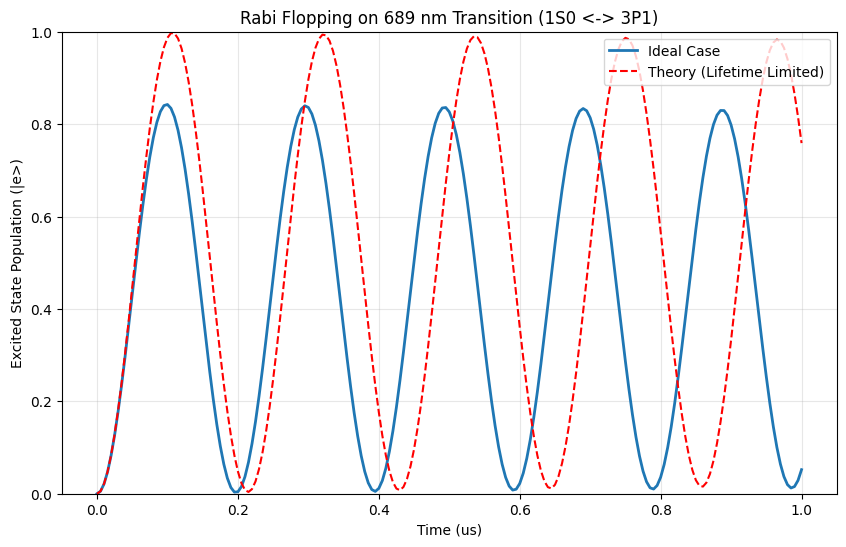

Pi Time: 0.09999999999999999 us
Pi/2 Time [theory]: 0.0536492518287594 us
Rabi Frequency [theory]: 4.659897230216062 MHz


In [16]:
cloud_radii = 0e-6

w0 = 0.5e-3
w1, w2 = 0.9e-3,0.9e-3

P_689 = 21e-3 * (np.sqrt(3)/4)
P_688 = 0
P_679 = 0

temp = 0e-6
N_atoms = 2
T_MAX = 1e-6

theta_1, theta_1z = np.radians(59.4384), 0.0
theta_2, theta_2z = np.radians(-59.64), 0.0
theta_0, theta_0z = 0.0, 0.0

def get_k_hat(theta, theta_z):
        return np.array([np.cos(theta_z)*np.cos(theta), np.cos(theta_z)*np.sin(theta), np.sin(theta_z)])

k_hat_0, k_hat_1, k_hat_2 = get_k_hat(theta_0, theta_0z), get_k_hat(theta_1, theta_1z), get_k_hat(theta_2, theta_2z)
k_vec_0, k_vec_1, k_vec_2 = k_hat_0 * (2*PI/lambda_689), k_hat_1 * (2*PI/lambda_688), k_hat_2 * (2*PI/lambda_679)

print("Simulating ideal one photon dynamics... ")

# ideal case
pos,vel = sample_atomic_ensemble(cloud_radii, temp, n_samples=N_atoms)
tlist, pop_ideal = simulate_one_photon_rabi_dynamics(pos, vel, d0=0, t_max=T_MAX, dt=5e-9, detuning=2*PI* 2e6)

Omega_theory = gamma_689 * np.sqrt(P_689 * 100/ (PI*w0**2) / Is_689)

plt.figure(figsize=(10, 6))

plt.plot(tlist * 1e6, pop_ideal, label="Ideal Case", linewidth=2)
plt.plot(tlist * 1e6, (0.5 - 0.5*np.cos(Omega_theory * tlist )*np.exp(-3/4*tlist * gamma_689)) , 'r--', label='Theory (Lifetime Limited)')


plt.title("Rabi Flopping on 689 nm Transition (1S0 <-> 3P1)")
plt.xlabel("Time (us)")
plt.ylabel("Excited State Population (|e>)")
plt.ylim(0, 1)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)


plt.show()


print(f"Pi Time: {tlist[np.argmax(pop_ideal)]*1e6} us")
print(f"Pi/2 Time [theory]: {PI/2/Omega_theory*1e6} us")
print(f"Rabi Frequency [theory]: {Omega_theory / (2*PI)*1e-6} MHz")


Uses 3/4 for damping rate. This seems to be the case for certain cases (semiclassical, strong drive, pure dephasing, etc.) A bit confused, but this matches sims

# 1 Photon Ramsey Oscillations

In [17]:
def simulate_ramsey_fringes(positions, velocities, scan_type='time', scan_vals=None, 
                            fixed_T=2e-6, fixed_phi=0.0, t_pulse=200e-9, d0=0, detune=0.0):
    N_atoms = positions.shape[0]
    n_steps = len(scan_vals)
    
    # Define Quantum Operators
    g = qt.basis(2, 0)
    e = qt.basis(2, 1)
    sm = qt.destroy(2)
    sp = qt.create(2)
    proj_e = sp * sm
    
    rho0 = g * g.dag()
    c_ops = [np.sqrt(gamma_689) * sm]
    
    avg_population = np.zeros(n_steps)
    
    # Calculate all local parameters based on position and velocity
    params = get_calculated_parameters(positions, velocities, d=[d0, 0, 0])
    
    for i in tqdm(range(N_atoms), desc=f"Simulating Ramsey ({scan_type} scan)"):
        dshift = params['beam_0']['dshift'][i] + detune
        rabi = params['beam_0']['Omega'][i]
        
        # --- 1. First pi/2 Pulse (Phase = 0) ---
        H1 = 0.5 * (rabi * qt.sigmax() - dshift * qt.sigmaz())
        res1 = qt.mesolve(H1, rho0, [0, t_pulse], c_ops, [])
        rho1 = res1.states[-1]
        
        # --- 2. Dark Time & Second Pulse ---
        H_dark = -0.5 * dshift * qt.sigmaz()
        if scan_type == 'time':
            tlist_dark = scan_vals
            # QuTiP requires the time array to start at 0 for proper state initialization.
            
                
            # Evolve dark time for all requested durations at once
            res_dark = qt.mesolve(H_dark, rho1, tlist_dark, c_ops, [])
            dark_states = res_dark.states
            
            # Apply second pulse to each resulting state
            H2 = 0.5 * (rabi * (np.cos(fixed_phi) * qt.sigmax() + np.sin(fixed_phi) * qt.sigmay()) - dshift * qt.sigmaz())
            
            for j, rho2 in enumerate(dark_states):
                res2 = qt.mesolve(H2, rho2, [0, t_pulse], c_ops, [proj_e])
                avg_population[j] += res2.expect[0][-1]
                
        elif scan_type == 'phase':
            
            res_dark = qt.mesolve(H_dark, rho1, [0, fixed_T], c_ops, [])
            rho2 = res_dark.states[-1]
                
            # Scan the phase of the second pulse
            for j, phi in enumerate(scan_vals):
                H2 = 0.5 * (rabi * (np.cos(phi) * qt.sigmax() + np.sin(phi) * qt.sigmay()) - dshift * qt.sigmaz())
                res2 = qt.mesolve(H2, rho2, [0, t_pulse], c_ops, [proj_e])
                avg_population[j] += res2.expect[0][-1]

    return scan_vals, avg_population / N_atoms



## Ideal Ramsey Fringes

Simulating Ramsey (time scan): 100%|█████████████████████████████████████████████████| 100/100 [00:07<00:00, 13.91it/s]


NameError: name 'pop_p_ideal' is not defined

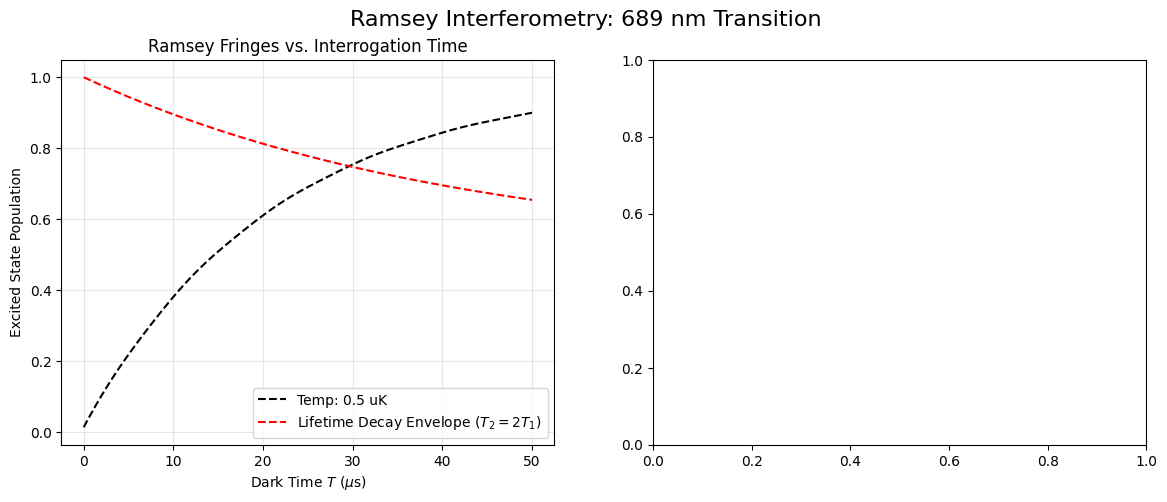

In [ ]:

N_atoms = 100

# ideal case
pos,vel = sample_atomic_ensemble(0e-6,0.0e-6,n_samples=N_atoms)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Ramsey Interferometry: 689 nm Transition", fontsize=16)

# ---------------------------------------------------------
# Test 1: Time Scan (Fixed Phase = 0)
# ---------------------------------------------------------
t_scan = np.linspace(0, 50e-6, 150)

_, pop_t_ideal = simulate_ramsey_fringes(pos, vel, scan_type='time', 
                                         scan_vals=t_scan, fixed_phi=0.0, t_pulse=0.3235e-6, detune=2*PI*100e3)


axs[0].plot(t_scan * 1e6, pop_t_ideal, 'k--', label="Temp: 0.5 uK")
axs[0].plot(t_scan * 1e6, 0.5 + 0.5 * np.exp(-t_scan*gamma_689/2), 'r--', label=r"Lifetime Decay Envelope ($T_2=2T_1$)")

axs[0].set_title("Ramsey Fringes vs. Interrogation Time")
axs[0].set_xlabel(r"Dark Time $T$ ($\mu$s)")
axs[0].set_ylabel("Excited State Population")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# ---------------------------------------------------------
# Test 2: Phase Scan (Fixed Time = 2 us)
# ---------------------------------------------------------
phi_scan = np.linspace(0, 4 * np.pi, 150)
fixed_T = 2e-6

# _, pop_p_ideal = simulate_ramsey_fringes(pos, vel, scan_type='phase', 
#                                          scan_vals=phi_scan, fixed_T=fixed_T, t_pulse=0.3235e-6, detune=2*PI*100e3)


# X-axis ticks in terms of Pi
pi_ticks = [0, np.pi, 2*np.pi, 3*np.pi, 4*np.pi]
pi_labels = ['0', r'$\pi$', r'$2\pi$', r'$3\pi$', r'$4\pi$']

# axs[1].plot(phi_scan, pop_p_ideal, 'k--', label="Ideal (0K)")
axs[1].set_title(f"Ramsey Fringes vs. Phase Offset (T = {fixed_T*1e6} $\mu$s)")
axs[1].set_xlabel("Second Pulse Phase $\phi$ (rad)")
axs[1].set_ylabel("Excited State Population")
axs[1].set_xticks(pi_ticks)
axs[1].set_xticklabels(pi_labels)
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Finite Size Ramsey Simulations

In [ ]:


N_atoms = 50


pos1,vel1 = sample_atomic_ensemble(0e-6,0.0e-6,n_samples=2)
pos2,vel2 = sample_atomic_ensemble(100e-6,0.0e-6,n_samples=N_atoms)
pos3,vel3 = sample_atomic_ensemble(250e-6,0.0e-6,n_samples=N_atoms)
pos4,vel4 = sample_atomic_ensemble(500e-6,0.0e-6,n_samples=N_atoms)

detuning = 100e3 * 2*PI

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Ramsey Interferometry: 689 nm Transition (Finite Size)", fontsize=16)

# ---------------------------------------------------------
# Test 1: Time Scan (Fixed Phase = 0)
# ---------------------------------------------------------
t_scan = np.linspace(0, 50e-6, 150)


_, pop_t_ideal = simulate_ramsey_fringes(pos1,vel1, scan_type='time', 
                                         scan_vals=t_scan, fixed_phi=0.0, t_pulse=0.3235e-6, detune=detuning)
_, pop_t_100um = simulate_ramsey_fringes(pos2,vel2, scan_type='time', 
                                         scan_vals=t_scan, fixed_phi=0.0, t_pulse=0.3235e-6, detune=detuning)
_, pop_t_250um = simulate_ramsey_fringes(pos3,vel3, scan_type='time', 
                                         scan_vals=t_scan, fixed_phi=0.0, t_pulse=0.3235e-6, detune=detuning)
_, pop_t_500um = simulate_ramsey_fringes(pos4,vel4, scan_type='time', 
                                         scan_vals=t_scan, fixed_phi=0.0, t_pulse=0.3235e-6, detune=detuning)



axs[0].plot(t_scan * 1e6, pop_t_ideal, '--', label="wa = 0 um")
axs[0].plot(t_scan * 1e6, pop_t_100um,  '--', label="wa = 100 um")
axs[0].plot(t_scan * 1e6, pop_t_250um, '--', label="wa = 250 um")
axs[0].plot(t_scan * 1e6, pop_t_500um, '--', label="wa = 500 um")

axs[0].plot(t_scan * 1e6, 0.5 + 0.5 * np.exp(-t_scan*gamma_689/2), 'r--', label="Lifetime Decay Envelope ($T_2=2T_1$)")

axs[0].set_title("Ramsey Fringes vs. Interrogation Time")
axs[0].set_xlabel("Dark Time $T$ ($\mu$s)")
axs[0].set_ylabel("Excited State Population")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# ---------------------------------------------------------
# Test 2: Phase Scan (Fixed Time = 2 us)
# ---------------------------------------------------------
phi_scan = np.linspace(0, 4 * np.pi, 150)
fixed_T = 1e-6

_, pop_p_ideal = simulate_ramsey_fringes(pos1, vel1, scan_type='phase', 
                                         scan_vals=phi_scan, fixed_T=fixed_T, t_pulse=0.3235e-6, detune=detuning)
_, pop_p_100um = simulate_ramsey_fringes(pos2, vel2, scan_type='phase', 
                                         scan_vals=phi_scan, fixed_T=fixed_T, t_pulse=0.3235e-6, detune=detuning)
_, pop_p_250um = simulate_ramsey_fringes(pos3, vel3, scan_type='phase', 
                                         scan_vals=phi_scan, fixed_T=fixed_T, t_pulse=0.3235e-6, detune=detuning)
_, pop_p_500um = simulate_ramsey_fringes(pos4, vel4, scan_type='phase', 
                                         scan_vals=phi_scan, fixed_T=fixed_T, t_pulse=0.3235e-6, detune=detuning)


# X-axis ticks in terms of Pi
pi_ticks = [0, np.pi, 2*np.pi, 3*np.pi, 4*np.pi]
pi_labels = ['0', '$\pi$', '$2\pi$', '$3\pi$', '$4\pi$']

axs[1].plot(phi_scan, pop_p_ideal, '--', label="wa = 0 um")
axs[1].plot(phi_scan, pop_p_100um,  '--', label="wa = 100 um")
axs[1].plot(phi_scan, pop_p_250um, '--', label="wa = 250 um")
axs[1].plot(phi_scan, pop_p_500um, '--', label="wa = 500 um")




axs[1].set_title(f"Ramsey Fringes vs. Phase Offset (T = {fixed_T*1e6} $\mu$s)")
axs[1].set_xlabel("Second Pulse Phase $\phi$ (rad)")
axs[1].set_ylabel("Excited State Population")
axs[1].set_xticks(pi_ticks)
axs[1].set_xticklabels(pi_labels)
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Finite Temperature Ramsey Simulations

In [ ]:
N_atoms = 150


pos1,vel1 = sample_atomic_ensemble(0e-6,0.0e-6,n_samples=2)
pos2,vel2 = sample_atomic_ensemble(0e-6,1.0e-6,n_samples=N_atoms)
pos3,vel3 = sample_atomic_ensemble(0e-6,5.0e-6,n_samples=N_atoms)
pos4,vel4 = sample_atomic_ensemble(0e-6,15.0e-6,n_samples=N_atoms)

detuning = 300e3 * 2*PI

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Ramsey Interferometry: 689 nm Transition (Finite Temperature)", fontsize=16)

# ---------------------------------------------------------
# Test 1: Time Scan (Fixed Phase = 0)
# ---------------------------------------------------------
t_scan = np.linspace(0, 30e-6, 150)


_, pop_t_ideal = simulate_ramsey_fringes(pos1,vel1, scan_type='time', 
                                         scan_vals=t_scan, fixed_phi=0.0, t_pulse=0.3235e-6, detune=detuning)
_, pop_t_1uk = simulate_ramsey_fringes(pos2,vel2, scan_type='time', 
                                         scan_vals=t_scan, fixed_phi=0.0, t_pulse=0.3235e-6, detune=detuning)
_, pop_t_5uk = simulate_ramsey_fringes(pos3,vel3, scan_type='time', 
                                         scan_vals=t_scan, fixed_phi=0.0, t_pulse=0.3235e-6, detune=detuning)
_, pop_t_15uk = simulate_ramsey_fringes(pos4,vel4, scan_type='time', 
                                         scan_vals=t_scan, fixed_phi=0.0, t_pulse=0.3235e-6, detune=detuning)



axs[0].plot(t_scan * 1e6, pop_t_ideal, '--', label="T = 0 uK")
axs[0].plot(t_scan * 1e6, pop_t_1uk,  '--', label="T = 1 uK")
axs[0].plot(t_scan * 1e6, pop_t_5uk, '--', label="T = 5 uK")
axs[0].plot(t_scan * 1e6, pop_t_15uk, '--', label="T = 15 uK")

axs[0].plot(t_scan * 1e6, 0.5 + 0.5 * np.exp(-t_scan*gamma_689/2), 'r--', label="Lifetime Decay Envelope ($T_2=2T_1$)")

axs[0].set_title("Ramsey Fringes vs. Interrogation Time")
axs[0].set_xlabel("Dark Time $T$ ($\mu$s)")
axs[0].set_ylabel("Excited State Population")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# ---------------------------------------------------------
# Test 2: Phase Scan (Fixed Time = 2 us)
# ---------------------------------------------------------
phi_scan = np.linspace(0, 4 * np.pi, 50)
fixed_T = 1e-6

_, pop_p_ideal = simulate_ramsey_fringes(pos1, vel1, scan_type='phase', 
                                         scan_vals=phi_scan, fixed_T=fixed_T, t_pulse=0.3235e-6, detune=detuning)
_, pop_p_1uk = simulate_ramsey_fringes(pos2, vel2, scan_type='phase', 
                                         scan_vals=phi_scan, fixed_T=fixed_T, t_pulse=0.3235e-6, detune=detuning)
_, pop_p_5uk = simulate_ramsey_fringes(pos3, vel3, scan_type='phase', 
                                         scan_vals=phi_scan, fixed_T=fixed_T, t_pulse=0.3235e-6, detune=detuning)
_, pop_p_15uk = simulate_ramsey_fringes(pos4, vel4, scan_type='phase', 
                                         scan_vals=phi_scan, fixed_T=fixed_T, t_pulse=0.3235e-6, detune=detuning)


# X-axis ticks in terms of Pi
pi_ticks = [0, np.pi, 2*np.pi, 3*np.pi, 4*np.pi]
pi_labels = ['0', '$\pi$', '$2\pi$', '$3\pi$', '$4\pi$']

axs[1].plot(phi_scan, pop_p_ideal, '--', label="T = 0 uK")
axs[1].plot(phi_scan, pop_p_1uk,  '--', label="T = 1 uK")
axs[1].plot(phi_scan, pop_p_5uk, '--', label="T = 5 uK")
axs[1].plot(phi_scan, pop_p_15uk, '--', label="T = 15 uK")




axs[1].set_title(f"Ramsey Fringes vs. Phase Offset (T = {fixed_T*1e6} $\mu$s)")
axs[1].set_xlabel("Second Pulse Phase $\phi$ (rad)")
axs[1].set_ylabel("Excited State Population")
axs[1].set_xticks(pi_ticks)
axs[1].set_xticklabels(pi_labels)
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Three Photon Rabi Oscillations

In [25]:
# --- QUTIP SIMULATION ---
def simulate_three_photon_rabi_dynamics(positions, velocities, Delta1, Delta2, Delta3, d0=0, t_max=20e-6, dt=10e-9):
    """
    Simulates the atomic ensemble using the QuTiP master equation.
    Returns the time array and the averaged excited state population.
    """
    N_atoms = positions.shape[0]
    n_steps = int(t_max/dt) + 1
    tlist = np.linspace(0, t_max, n_steps)
    
    # Define Quantum Operators for a 2-level system
    g = qt.basis(4, 0)  # Ground state |g> (1S0)
    e = qt.basis(4, 1)  # Excited state |e> (3P1)
    v = qt.basis(4, 2)  # Virtual state |v> (3S1)
    r = qt.basis(4, 3)  # Final state |r> (3P0)
    

    # projection operators
    proj_g = g * g.dag()
    proj_e = e * e.dag()
    proj_v = v * v.dag()
    proj_r = r * r.dag()

    # Transition operators (Off-diagonal elements)
    sig_01 = g * e.dag()  # 689nm transition (|0><1|)
    sig_12 = e * v.dag()  # 688nm transition (|1><2|)
    sig_32 = r * v.dag()  # 679nm transition (|3><2|)

    # Initial state (all atoms in ground state)
    rho0 = proj_g

    c_ops = [
        np.sqrt(gamma_689) * sig_01,  # |e> -> |g>
        np.sqrt(gamma_688) * sig_12,  # |v> -> |e>
        np.sqrt(gamma_679) * sig_32   # |v> -> |r>
    ]

    
    avg_populations = np.zeros((n_steps, 4))
    params = get_calculated_parameters(positions, velocities)

    
    for i in range(N_atoms):

        # Unpack local parameters for this specific atom
        _, rabi_0 = params['beam_0']['dshift'][i], params['beam_0']['Omega'][i]
        _, rabi_1 = params['beam_1']['dshift'][i], params['beam_1']['Omega'][i]
        _, rabi_2 = params['beam_2']['dshift'][i], params['beam_2']['Omega'][i]
        # forming the RWA hamiltonian    

        H_diag = - Delta1 * proj_e - (Delta2 - Delta1) * proj_v - Delta3 * proj_r
        print(Delta1 / (2*PI*1e6))
        print((Delta2 - Delta1) / (2*PI*1e6))
        print(Delta3 / (2*PI*1e6))
                 
        H_drive = 0.5 * (rabi_0 * (sig_01 + sig_01.dag()) + 
                         rabi_1 * (sig_12 + sig_12.dag()) + 
                         rabi_2 * (sig_32 + sig_32.dag()))
        
        H = H_diag + H_drive
        
        # Solve the master equation
        result = qt.mesolve(H, rho0, tlist, c_ops, [proj_g, proj_e, proj_v, proj_r])
        
        #Transpose the result and add to the full array
        avg_populations = avg_populations + (np.array(result.expect).T)
        
    return tlist, avg_populations / N_atoms



Detunings:
Delta1 = 2pi x 45.0 MHz  
Delta2 = 2pi x 399.99999999999994 MHz  
Delta3 = 2pi x -0.5 MHz  
DwB = 2pi x 40.0 MHz  

Powers:  
689: 28.0 mW 
688: 4.8 mW 
679: 4.8 mW


Rabi Freqs:  
689: 4.088513098477772 MHz 
688: 38.53343275506263 MHz 
679: 21.486721947329123 MHz


Raman Rabi Freq: 1.034946444105169 MHz
Pi time: 0.483116786233618 us


3v Rabi Freq: 0.4231392092946979 MHz
Pi time: 1.1816442178294377 us

AC Stark Shift: -596.4119828139642 kHz
Running 3-Photon Flop Simulation...
4.9999999999999964
395.0
-0.5
4.9999999999999964
395.0
-0.5


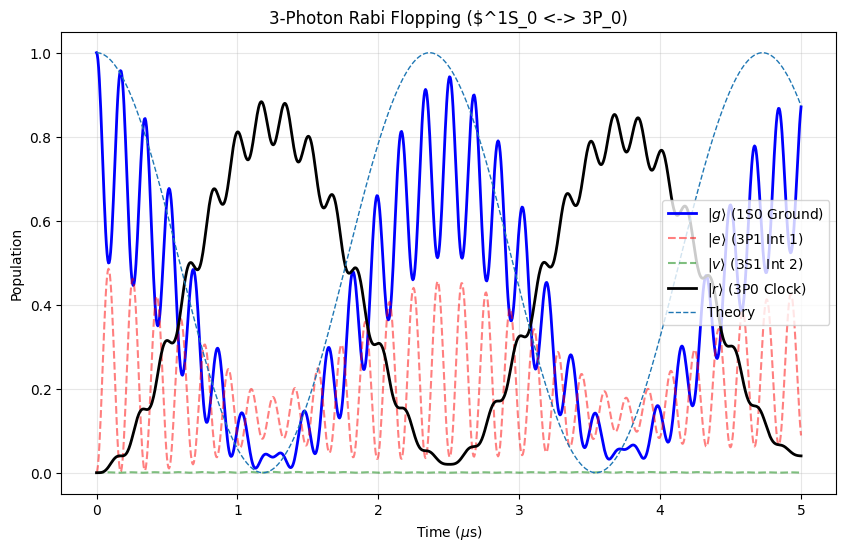

In [26]:
theta_1, theta_1z = np.radians(59.4384), 0.0
theta_2, theta_2z = np.radians(-59.64), 0.0
theta_0, theta_0z = 0.0, 0.0

# --- BEAM / CLOUD PARAMETERS ---
wa = 0
w0, w1, w2 = [1e-3]*3
tx, ty, tz = [0e-6]*3
P_689, P_688, P_679 = 28e-3, 4.8e-3, 4.8e-3
#
k_hat_0, k_hat_1, k_hat_2 = get_k_hat(theta_0, theta_0z), get_k_hat(theta_1, theta_1z), get_k_hat(theta_2, theta_2z)
k_vec_0, k_vec_1, k_vec_2 = k_hat_0 * (2*PI/lambda_689), k_hat_1 * (2*PI/lambda_688), k_hat_2 * (2*PI/lambda_679)

N_ATOMS = 2
pos, vel = sample_atomic_ensemble(wa, tx, n_samples=N_ATOMS)

# 2. Define massive detunings to avoid intermediate scattering
D1  = 2*PI * 45e6  # one photon detuning
DwB = 2*PI * 40e6  # Zeeman shift
D2  = 2*PI * 400e6
D3  = - 2*PI * 500e3

params = get_calculated_parameters(pos, vel)
O1_nom = np.mean(params['beam_0']['Omega'])
O2_nom = np.mean(params['beam_1']['Omega'])
O3_nom = np.mean(params['beam_2']['Omega'])

print(f"Detunings:\nDelta1 = 2pi x {D1 / (2*PI) * 1e-6} MHz  \nDelta2 = 2pi x {D2 / (2*PI) * 1e-6} MHz  \nDelta3 = 2pi x {D3 / (2*PI) * 1e-6} MHz  \nDwB = 2pi x {DwB / (2*PI) * 1e-6} MHz  \n")
print(f"Powers:  \n689: {P_689*1e3} mW \n688: {P_688*1e3} mW \n679: {P_679*1e3} mW\n\n")
print(f"Rabi Freqs:  \n689: {O1_nom / (2*PI) * 1e-6} MHz \n688: {O2_nom / (2*PI) * 1e-6} MHz \n679: {O3_nom / (2*PI) * 1e-6} MHz\n\n")
print(f"Raman Rabi Freq: {O2_nom * O3_nom / 2 / D2 / 2 / PI * 1e-6} MHz")
print(f"Pi time: {0.5 * (O2_nom * O3_nom / 2 / D2 / 2 / PI * 1e-6)**-1} us\n\n")

print(f"3v Rabi Freq: {O1_nom * O2_nom * O3_nom / (4 * D2 *(D1 - DwB))/ (2 * PI) * 1e-6} MHz")
print(f"Pi time: {0.5 * (O1_nom * O2_nom * O3_nom / (4 * D2 *(D1 - DwB))/ (2 * PI) * 1e-6)**-1} us")
print('')
print(f"AC Stark Shift: {(-O1_nom**2 /2 * D1 / (D1**2 - DwB**2) + O3_nom**2/(4*D2)) / (2*PI) * 1e-3} kHz")

O3v = O1_nom * O2_nom * O3_nom / (4 * D2 *(D1 - DwB))
t_max = 5e-6 

print("Running 3-Photon Flop Simulation...")
tlist, pops = simulate_three_photon_rabi_dynamics(
    pos, vel, 
    Delta1=D1-DwB, Delta2=D2, Delta3=D3, 
    t_max=t_max, dt=5e-9
)


# 3. Plotting
plt.figure(figsize=(10, 6))
plt.plot(tlist * 1e6, pops[:, 0], 'b-', linewidth=2, label=r'$|g\rangle$ (1S0 Ground)')
plt.plot(tlist * 1e6, pops[:, 1], 'r--', alpha=0.5, label=r'$|e\rangle$ (3P1 Int 1)')
plt.plot(tlist * 1e6, pops[:, 2], 'g--', alpha=0.5, label=r'$|v\rangle$ (3S1 Int 2)')
plt.plot(tlist * 1e6, pops[:, 3], 'k-', linewidth=2, label=r'$|r\rangle$ (3P0 Clock)')
plt.plot(tlist * 1e6, 0.5 + 0.5*np.cos(tlist*O3v), '--', linewidth=1, label=r'Theory')
plt.title(r"3-Photon Rabi Flopping ($^1S_0 <-> 3P_0)")
plt.xlabel(r"Time ($\mu$s)")
plt.ylabel("Population")
plt.ylim([-0.05, 1.05])
plt.legend(loc="center right")
plt.grid(True, alpha=0.3)
plt.show()

Sweeping Delta_3 to find the AC Stark shifted resonance...


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:35<00:00,  1.18s/it]
C:\Users\Erik\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Erik\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Erik\AppData\Local\Temp\ipykernel_32384\3226300001.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


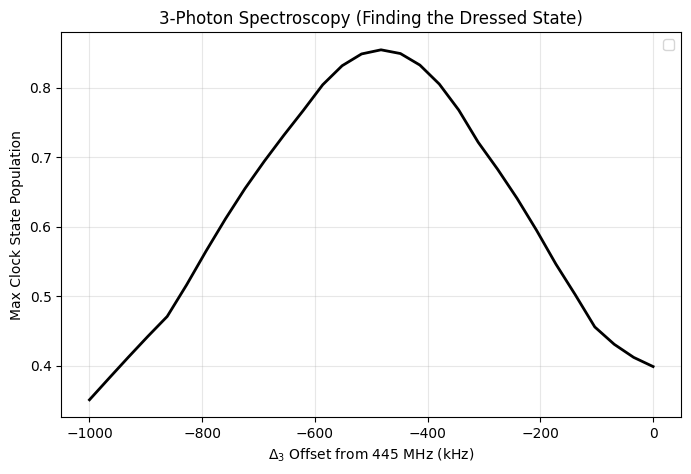

In [23]:
N_ATOMS = 1
pos = np.zeros((N_ATOMS, 3))
vel = np.zeros((N_ATOMS, 3))

offset_range = np.linspace(-1e6,  -0e6, 30) * 2 * PI 
max_transfer = []

# Increase t_max slightly to ensure we catch the peak of the slow 3-photon flop
t_max_sweep = 100e-6 

D1  = 2*PI * 45e6  # one photon detuning
DwB = 2*PI * 40e6  # Zeeman shift
D2  = 2*PI * 400e6
D3  = 2*PI * 0

print("Sweeping Delta_3 to find the AC Stark shifted resonance...")

for offset in tqdm(offset_range):
    D3_test = D3 + offset
    
    # Run the simulation for this specific detuning
    tlist, pops = simulate_three_photon_rabi_dynamics(
        pos, vel, 
        Delta1=D1-DwB, Delta2=D2, Delta3=D3_test, 
        t_max=t_max_sweep, dt=200e-9
    )
    
    # Record the maximum population that made it to the Clock state
    max_transfer.append(np.max(pops[:, 3]))

# Plot the Spectroscopy scan
plt.figure(figsize=(8, 5))
plt.plot(offset_range / (2 * PI * 1e3), max_transfer, 'k-', linewidth=2)
# plt.axvline(0, color='r', linestyle='--', label="Bare Resonance (0 offset)")
plt.title("3-Photon Spectroscopy (Finding the Dressed State)")
plt.xlabel(r"$\Delta_3$ Offset from 445 MHz (kHz)")
plt.ylabel("Max Clock State Population")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## TODO

- xxx  ramsey fringes
- xxxx simple temp and finite beam size dynamics
- three photon dynamics
- finite laser linewidth + phase noise
- extra levels,etc
